### MLFlow practice - With custom weather signal. 
#### Usage, Serving, Inference and Analysis items below.

In [2]:
## ===============================================================================
## Basic Import and Smoke Tests for Synthetic Weather Signal
## ===============================================================================


import sys, os

# 1) Add the ROOT (MLFlow_Synth_TimeSeries_Lab) to sys.path
root_path = os.path.abspath("..")  # from src_notebooks up to root
sys.path.append(root_path)
print(f"ROOT path added to sys.path: {root_path}")

from src.signal_gen import SyntheticWeatherSignal, SignalConfig
from src.utils import create_lagged_features, compute_regression_metrics


cfg = SignalConfig(length=2000, years=4.0, noise_std=2.0, seed=42)
gen = SyntheticWeatherSignal(cfg)
df = gen.generate()

df[["t", "temp"]].head()


ROOT path added to sys.path: d:\JoelDesktop folds_24\NEU FALL2025\MLops IE7374 18008\MasterRepo & LabRepo\mlops-labs-portfolio\MLFlow_Synth_TimeSeries_Lab


,t,temp
0,0.0,4.428305
1,1.0,0.675579
2,2.0,1.051409
3,3.0,4.833198
4,4.0,5.863606


In [3]:
## ===============================================================================
## Basic Import and Smoke Tests for Random Forest Training
## ===============================================================================

from sklearn.ensemble import RandomForestRegressor

X, y = create_lagged_features(df["temp"], window_size=60)
X_train, y_train = X[:1000], y[:1000]
X_test, y_test   = X[1000:], y[1000:]

rf = RandomForestRegressor(n_estimators=100, random_state=0)
rf.fit(X_train, y_train)
preds = rf.predict(X_test)

compute_regression_metrics(y_test, preds)


{'rmse': 2.9785927135312544,
 'mae': 2.320149498391626,
 'r2': 0.8605783869535116,
 'smape': np.float64(36.67249839452936)}

In [3]:
# Single run (imitating terminal)
%run ../src/train_rf.py --window-size 60 --n-estimators 300 --max-depth 20

# Optuna sweep
%run ../src/tune_rf_optuna.py --n-trials 10


d:\JoelDesktop folds_24\NEU FALL2025\MLops IE7374 18008\MasterRepo & LabRepo\mlops-labs-portfolio\MLFlow_Synth_TimeSeries_Lab\weather_venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:140: FutureWarning: Filesystem tracking backend (e.g., './mlruns') is deprecated. Please switch to a database backend (e.g., 'sqlite:///mlflow.db'). For feedback, see: https://github.com/mlflow/mlflow/issues/18534
  return FileStore(store_uri, store_uri)
2025/11/17 14:31:34 INFO mlflow.tracking.fluent: Experiment with name 'synthetic_weather_rf' does not exist. Creating a new experiment.
2025/11/17 14:31:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/17 14:31:38 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2025/11/17 14:31:38 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_exampl

=== Test metrics ===
rmse: 2.4521
mae: 1.9533
r2: 0.9033
smape: 35.8047


2025/11/17 14:31:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/17 14:31:42 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2025/11/17 14:31:42 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
[I 2025-11-17 14:31:42,460] Trial 0 finished with value: 2.462502696962286 and parameters: {'window_size': 48, 'n_estimators': 150, 'max_depth': 24, 'min_samples_leaf': 2}. Best is trial 0 with value: 2.462502696962286.
2025/11/17 14:31:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/17 14:31:46 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2025/11/17 14:31


=== Optuna best trial ===
Trial number: 4
Best val_rmse: 2.4483
Best params:
  window_size: 84
  n_estimators: 450
  max_depth: 40
  min_samples_leaf: 5


In [4]:
## ===============================================================================
## Re-run 
## ===============================================================================

# Optuna sweep
%run ../src/tune_rf_optuna.py --n-trials 35


d:\JoelDesktop folds_24\NEU FALL2025\MLops IE7374 18008\MasterRepo & LabRepo\mlops-labs-portfolio\MLFlow_Synth_TimeSeries_Lab\weather_venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:140: FutureWarning: Filesystem tracking backend (e.g., './mlruns') is deprecated. Please switch to a database backend (e.g., 'sqlite:///mlflow.db'). For feedback, see: https://github.com/mlflow/mlflow/issues/18534
  return FileStore(store_uri, store_uri)
[I 2025-11-17 14:47:44,973] A new study created in memory with name: rf_weather_study
2025/11/17 14:47:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/17 14:47:48 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2025/11/17 14:47:48 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer 


=== Optuna best trial ===
Trial number: 26
Best val_rmse: 2.4313
Best params:
  window_size: 36
  n_estimators: 250
  max_depth: 32
  min_samples_leaf: 3


## CELLS BELOW: 1-6 
1. DataFrame view of all Optuna trials.
2. Several param-, exploratory plots over trials.
3. Identify and inspect the best run.
4. Rebuild dataset, load best model, and evaluate.
5. Plot test predictions and log figure back to MLflow.

In [6]:
## Load all Optuna runs into a DataFrame
""" 
MLflow’s filter syntax supports only:
metrics.<key> <operator> <float>
params.<key> <operator> "string"
tags.<key> <operator> "string"

"""
import os
import sys
from pathlib import Path

import mlflow
from mlflow.tracking import MlflowClient

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure project root is on sys.path
root_path = Path("..").resolve()
sys.path.append(str(root_path))
print("Project root:", root_path)

from src.signal_gen import SyntheticWeatherSignal, SignalConfig
from src.utils import (
    create_lagged_features,
    train_val_test_split_time,
    compute_regression_metrics,
)

# Point MLflow at the root-level mlruns directory
mlruns_path = root_path / "mlruns"
mlflow.set_tracking_uri(mlruns_path.as_uri())
print("MLflow tracking URI:", mlruns_path.as_uri())

## ==============================================================================
# Load all Optuna trial runs from the experiment into a DataFrame

EXPERIMENT_NAME = "synthetic_weather_rf_optuna"

client = MlflowClient()
experiment = client.get_experiment_by_name(EXPERIMENT_NAME)
assert experiment is not None, f"Experiment {EXPERIMENT_NAME} not found"

experiment_id = experiment.experiment_id
print("Experiment ID:", experiment_id)

# Load ALL runs
all_runs = client.search_runs(
    experiment_ids=[experiment_id],
    max_results=5000,  # safe upper bound
    order_by=["metrics.val_rmse ASC"],
)

print("Total runs in experiment:", len(all_runs))

# Filter only Optuna trial runs by checking for this param:
optuna_runs = [r for r in all_runs if "optuna_trial_number" in r.data.params]

print("Optuna trial runs:", len(optuna_runs))

rows = []
for r in optuna_runs:
    p = r.data.params
    m = r.data.metrics

    rows.append(
        {
            "run_id": r.info.run_id,
            "trial": int(p.get("optuna_trial_number")),
            "window_size": int(p.get("window_size")),
            "n_estimators": int(p.get("n_estimators")),
            "max_depth": int(p.get("max_depth")),
            "min_samples_leaf": int(p.get("min_samples_leaf")),
            "val_rmse": m.get("val_rmse"),
            "val_mae": m.get("val_mae"),
            "val_r2": m.get("val_r2"),
            "val_smape": m.get("val_smape"),
            "test_rmse": m.get("test_rmse"),
            "test_smape": m.get("test_smape"),
        }
    )

df_runs = pd.DataFrame(rows).sort_values("val_rmse").reset_index(drop=True)
df_runs.head()





Project root: D:\JoelDesktop folds_24\NEU FALL2025\MLops IE7374 18008\MasterRepo & LabRepo\mlops-labs-portfolio\MLFlow_Synth_TimeSeries_Lab
MLflow tracking URI: file:///D:/JoelDesktop%20folds_24/NEU%20FALL2025/MLops%20IE7374%2018008/MasterRepo%20%26%20LabRepo/mlops-labs-portfolio/MLFlow_Synth_TimeSeries_Lab/mlruns
Experiment ID: 182908965022383957
Total runs in experiment: 47
Optuna trial runs: 45


,run_id,trial,window_size,n_estimators,max_depth,min_samples_leaf,val_rmse,val_mae,val_r2,val_smape,test_rmse,test_smape
0,9331542841344540b80f774d55239af8,26,36,250,32,3,2.431337,1.945124,0.894466,41.876175,2.500218,34.889762
1,4a0f0edde49a4496a48283b496ebfcdd,28,36,450,32,2,2.432120,1.948570,0.894398,41.956286,2.488658,35.169886
2,1c241982132f43edb87b1315b6bce6dc,29,36,450,28,2,2.432120,1.948570,0.894398,41.956286,2.488658,35.169886
3,96f115811601406eacaa2a686c8302a0,31,36,450,20,2,2.432442,1.949205,0.894370,41.962150,2.488966,35.169587
4,210debf91c694ecd91155e0b81f6e43b,30,36,450,20,2,2.432442,1.949205,0.894370,41.962150,2.488966,35.169587


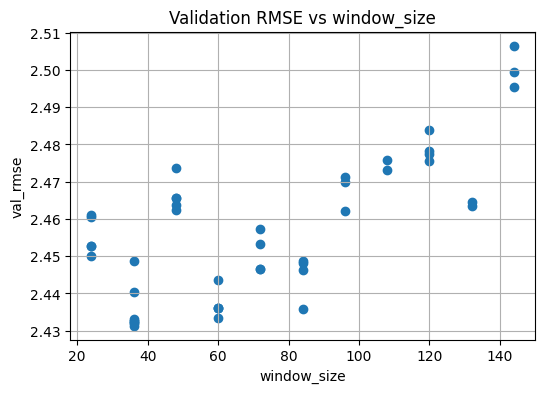

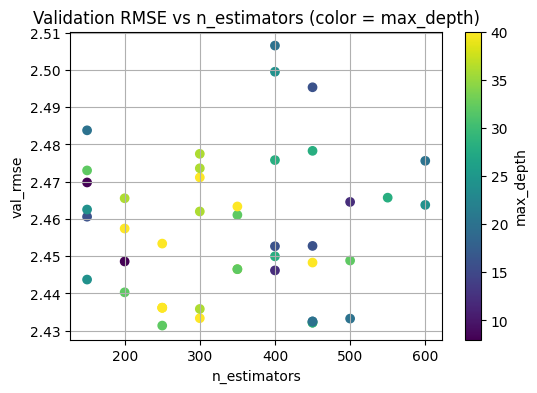

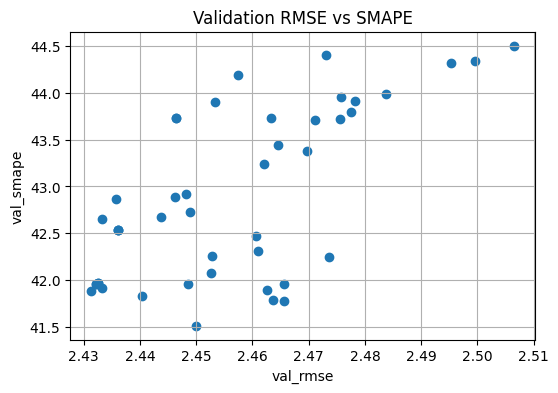

In [7]:
## Quick exploratory plots over trials

# 1) RMSE vs window_size
plt.figure(figsize=(6, 4))
plt.scatter(df_runs["window_size"], df_runs["val_rmse"])
plt.xlabel("window_size")
plt.ylabel("val_rmse")
plt.title("Validation RMSE vs window_size")
plt.grid(True)
plt.show()

# 2) RMSE vs n_estimators, colored by max_depth
plt.figure(figsize=(6, 4))
scatter = plt.scatter(
    df_runs["n_estimators"],
    df_runs["val_rmse"],
    c=df_runs["max_depth"],
    cmap="viridis",
)
plt.xlabel("n_estimators")
plt.ylabel("val_rmse")
plt.title("Validation RMSE vs n_estimators (color = max_depth)")
plt.colorbar(scatter, label="max_depth")
plt.grid(True)
plt.show()

# 3) val_rmse vs val_smape
plt.figure(figsize=(6, 4))
plt.scatter(df_runs["val_rmse"], df_runs["val_smape"])
plt.xlabel("val_rmse")
plt.ylabel("val_smape")
plt.title("Validation RMSE vs SMAPE")
plt.grid(True)
plt.show()



In [8]:
## Identify and inspect the best run

best_row = df_runs.iloc[0]
best_run_id = best_row["run_id"]

print("Best run ID:", best_run_id)
print("\nBest trial hyperparameters:")
display(best_row[["trial", "window_size", "n_estimators", "max_depth", "min_samples_leaf"]])

print("\nBest trial metrics (validation):")
display(best_row[["val_rmse", "val_mae", "val_r2", "val_smape"]])

print("\nBest trial metrics (test):")
display(best_row[["test_rmse", "test_smape"]])


Best run ID: 9331542841344540b80f774d55239af8

Best trial hyperparameters:


trial                26
window_size          36
n_estimators        250
max_depth            32
min_samples_leaf      3
Name: 0, dtype: object


Best trial metrics (validation):


val_rmse      2.431337
val_mae       1.945124
val_r2        0.894466
val_smape    41.876175
Name: 0, dtype: object


Best trial metrics (test):


test_rmse      2.500218
test_smape    34.889762
Name: 0, dtype: object

In [9]:
## Rebuild dataset, load best model, and evaluate
"""
Recreate the synthetic signal using the params from the best run.
Build lagged features with the best window_size.
Split train/val/test using the same fractions.
Load the trained RF model from MLflow.
Compute metrics and plot test predictions vs truth.
Log that plot back to the same MLflow run.
"""

# Fetch the full run object for parameter values
best_run = client.get_run(best_run_id)
p = best_run.data.params

length = int(p.get("length", 2000))
years = float(p.get("years", 4.0))
noise_std = float(p.get("noise_std", 2.0))
seed = int(p.get("seed", 42))
train_frac = float(p.get("train_frac", 0.6))
val_frac = float(p.get("val_frac", 0.2))
window_size = int(p["window_size"])

print("Reconstructing dataset with:")
print(f"  length={length}, years={years}, noise_std={noise_std}, seed={seed}")
print(f"  train_frac={train_frac}, val_frac={val_frac}, window_size={window_size}")

# Regenerate the same synthetic series
cfg = SignalConfig(
    length=length,
    years=years,
    noise_std=noise_std,
    seed=seed,
    include_components=False,
)
gen = SyntheticWeatherSignal(cfg)
df_signal = gen.generate()
series = df_signal["temp"]

# Build lagged dataset and splits
X, y = create_lagged_features(series, window_size=window_size)
(train, val, test) = train_val_test_split_time(X, y, train_frac=train_frac, val_frac=val_frac)
(X_train, y_train), (X_val, y_val), (X_test, y_test) = train, val, test

# Load the best model from MLflow
model_uri = f"runs:/{best_run_id}/model"
print("Loading model from:", model_uri)
best_model = mlflow.sklearn.load_model(model_uri)

y_pred_test = best_model.predict(X_test)
metrics_test = compute_regression_metrics(y_test, y_pred_test)
metrics_test



Reconstructing dataset with:
  length=2000, years=4.0, noise_std=2.0, seed=42
  train_frac=0.6, val_frac=0.2, window_size=36
Loading model from: runs:/9331542841344540b80f774d55239af8/model


{'rmse': 2.5002184252683013,
 'mae': 1.9824595378338972,
 'r2': 0.9018022968152755,
 'smape': np.float64(34.88976228682595)}

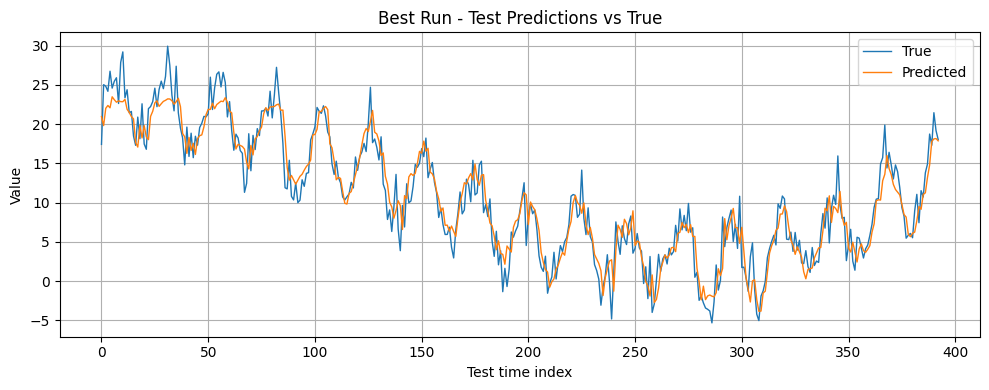

In [10]:
## Plot test predictions and log figure back to MLflow

# Plot test segment predictions vs truth
fig, ax = plt.subplots(figsize=(10, 4))

n = len(y_test)
indices = np.arange(n)

ax.plot(indices, y_test, label="True", linewidth=1.0)
ax.plot(indices, y_pred_test, label="Predicted", linewidth=1.0)
ax.set_title("Best Run - Test Predictions vs True")
ax.set_xlabel("Test time index")
ax.set_ylabel("Value")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

# Log this figure as an artifact under the same run
with mlflow.start_run(run_id=best_run_id):
    mlflow.log_figure(fig, "analysis/best_run_test_predictions.png")


In [ ]:
# %run ../src/train_rf.py --window-size 120 --noise-std 4.0 --n-estimators 400


# ## single run:
# %run ../src/train_rf.py --window-size 60 --n-estimators 300 --max-depth 20 --noise-std 2.0

# ## optuna sweep:
# %run ../src/tune_rf_optuna.py --n-trials 25 --noise-std 2.0


# ## MLflow UI in a terminal:
# mlflow ui

# cd MLFlow_Synth_TimeSeries_Lab
# mlflow ui

# ## In terminal:
# cd MLFlow_Synth_TimeSeries_Lab

# # Single RF run
# python -m src.train_rf --window-size 60 --n-estimators 300

# # Optuna sweep
# python -m src.tune_rf_optuna --n-trials 20
